<div align="center">

 LABSHEET - 4

</div>

SAKSHI(49)

1. Build a tool that computes and visualizes the 2D Fourier spectrum (magnitude and phase) of an image.

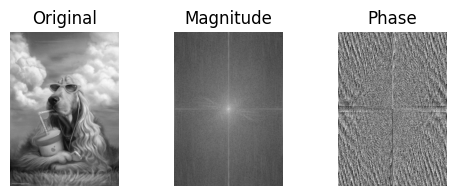

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img=cv2.imread("dog.jpg", 0)
f=np.fft.fft2(img)
fs=np.fft.fftshift(f)
magnitude=np.log(1+np.abs(fs))
phase=np.angle(fs)
plt.figure(figsize=(6,2))
plt.subplot(1,3,1)
plt.imshow(img,cmap="gray")
plt.title("Original")
plt.axis("off")
plt.subplot(1,3,2)
plt.imshow(magnitude,cmap="gray")
plt.title("Magnitude")
plt.axis("off")
plt.subplot(1,3,3)
plt.imshow(phase,cmap="gray")
plt.title("Phase")
plt.axis("off")
plt.show()

2. Develop a frequency-domain low-pass filter (ideal, Butterworth, and Gaussian) and compare the resulting blur effects.

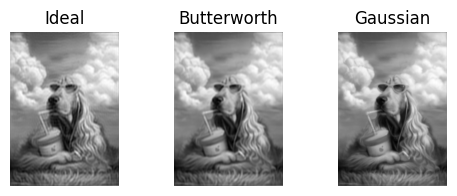

In [35]:
img=cv2.imread("dog.jpg",0)
rows,cols=img.shape
cy,cx=rows//2,cols//2
f=np.fft.fftshift(np.fft.fft2(img))
y,x=np.ogrid[:rows,:cols]
d=np.sqrt((x-cx)**2+(y-cy)**2)
D0=50
ideal=(d<=D0)
butter=1/(1+(d/D0)**8)
gaussian=np.exp(-(d**2)/(2*D0**2))
ideal_img=np.abs(np.fft.ifft2(np.fft.ifftshift(f*ideal)))
butter_img=np.abs(np.fft.ifft2(np.fft.ifftshift(f*butter)))
gaussian_img=np.abs(np.fft.ifft2(np.fft.ifftshift(f*gaussian)))
plt.figure(figsize=(6,2))
plt.subplot(1,3,1)
plt.imshow(ideal_img,cmap="gray")
plt.title("Ideal")
plt.axis("off")
plt.subplot(1,3,2)
plt.imshow(butter_img,cmap="gray")
plt.title("Butterworth")
plt.axis("off")
plt.subplot(1,3,3)
plt.imshow(gaussian_img,cmap="gray")
plt.title("Gaussian")
plt.axis("off")
plt.show()

3. Create a frequency-domain high-pass filter to enhance edges, and compare the result with spatial-domain edge detection.

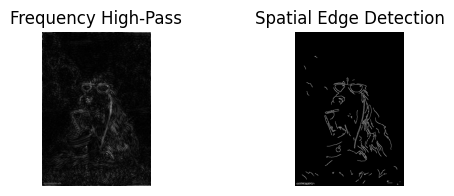

In [36]:
img=cv2.imread("dog.jpg",0)
rows,cols=img.shape
cy,cx=rows//2,cols//2
f=np.fft.fftshift(np.fft.fft2(img))
y,x=np.ogrid[:rows,:cols]
d=np.sqrt((x-cx)**2+(y-cy)**2)
high=(d>30)
highpass=np.abs(np.fft.ifft2(np.fft.ifftshift(f*high)))
edges=cv2.Canny(img,100,200)
plt.figure(figsize=(6,2))
plt.subplot(1,2,1)
plt.imshow(highpass,cmap="gray")
plt.title("Frequency High-Pass")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(edges,cmap="gray")
plt.title("Spatial Edge Detection")
plt.axis("off")
plt.show()

4. Build a periodic-noise removal tool that identifies and removes noise spikes visible in the frequency spectrum.

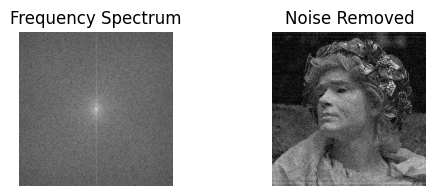

In [34]:
img=cv2.imread("statue.jpg",0)
f=np.fft.fftshift(np.fft.fft2(img))
spectrum=np.log(1+np.abs(f))
rows,cols=img.shape
cy,cx=rows//2,cols//2
mask=np.ones((rows,cols))
for dx,dy in [(40,0),(-40,0),(0,40),(0,-40)]:
    cv2.circle(mask,(cx+dx,cy+dy),8,0,-1)
clean=np.abs(np.fft.ifft2(np.fft.ifftshift(f*mask)))
plt.figure(figsize=(6,2))
plt.subplot(1,2,1)
plt.imshow(spectrum,cmap="gray")
plt.title("Frequency Spectrum")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(clean,cmap="gray")
plt.title("Noise Removed")
plt.axis("off")
plt.show()

5. Develop a program that compresses an image by retaining only the top-k Fourier coefficients and reconstructs it.

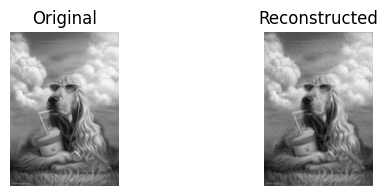

In [44]:
img=cv2.imread("dog.jpg",0)
f=np.fft.fftshift(np.fft.fft2(img))
k=5000
indices=np.argsort(np.abs(f).ravel())[-k:]
compressed=np.zeros_like(f)
compressed.ravel()[indices]=f.ravel()[indices]
reconstructed=np.abs(np.fft.ifft2(np.fft.ifftshift(compressed)))
plt.figure(figsize=(6,2))
plt.subplot(1,2,1)
plt.imshow(img,cmap="gray")
plt.title("Original")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(reconstructed,cmap="gray")
plt.title("Reconstructed")
plt.axis("off")
plt.show()

6. Create a watermark hide/reveal tool that embeds and extracts a watermark using frequency-domain manipulation.

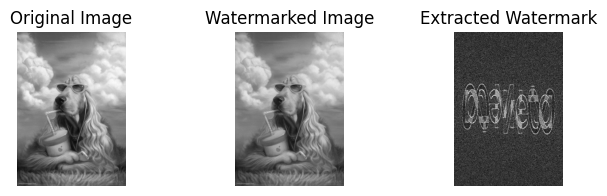

In [46]:
img = cv2.imread("dog.jpg", 0)
watermark = cv2.imread("meta.jpg", 0)
watermark = cv2.resize(watermark, (img.shape[1], img.shape[0]))
f = np.fft.fftshift(np.fft.fft2(img))
w = watermark / 255.0
alpha = 1000
fw = f + alpha * w
watermarked = np.abs(np.fft.ifft2(np.fft.ifftshift(fw)))
watermarked = np.uint8(np.clip(watermarked, 0, 255))
f2 = np.fft.fftshift(np.fft.fft2(watermarked))
extracted = np.abs((f2 - f) / alpha)
extracted = np.uint8(np.clip(extracted * 255, 0, 255))
plt.figure(figsize=(8, 2))
plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.subplot(1, 3, 2)
plt.imshow(watermarked, cmap="gray")
plt.title("Watermarked Image")
plt.axis("off")
plt.subplot(1, 3, 3)
plt.imshow(extracted, cmap="gray")
plt.title("Extracted Watermark")
plt.axis("off")
plt.show()

7. Build a band-pass / band-reject filter designer for isolating specific frequency ranges in a textured image.

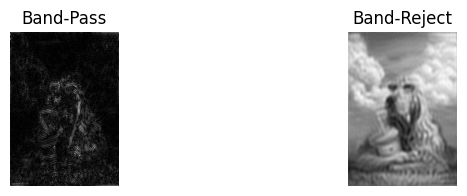

In [29]:
img=cv2.imread("dog.jpg",0)
rows,cols=img.shape
cy,cx=rows//2,cols//2
f=np.fft.fftshift(np.fft.fft2(img))
y,x=np.ogrid[:rows,:cols]
d=np.sqrt((x-cx)**2+(y-cy)**2)
low=30
high=80
bandpass=((d>=low)&(d<=high))
bandreject=((d<low)|(d>high))
bandpass_img=np.abs(np.fft.ifft2(np.fft.ifftshift(f*bandpass)))
bandreject_img=np.abs(np.fft.ifft2(np.fft.ifftshift(f*bandreject)))
plt.figure(figsize=(8,2))
plt.subplot(1,2,1)
plt.imshow(bandpass_img,cmap="gray")
plt.title("Band-Pass")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(bandreject_img,cmap="gray")
plt.title("Band-Reject")
plt.axis("off")
plt.show()

8. Develop a demo that swaps the phase and magnitude components between two images to show their relative importance.

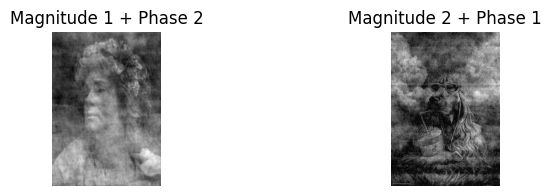

In [30]:
img1=cv2.imread("dog.jpg",0)
img2=cv2.imread("statue.jpg",0)
img2=cv2.resize(img2,(img1.shape[1],img1.shape[0]))
f1=np.fft.fft2(img1)
f2=np.fft.fft2(img2)
mag1=np.abs(f1)
mag2=np.abs(f2)
phase1=np.angle(f1)
phase2=np.angle(f2)
swap1=mag1*np.exp(1j*phase2)
swap2=mag2*np.exp(1j*phase1)
result1=np.abs(np.fft.ifft2(swap1))
result2=np.abs(np.fft.ifft2(swap2))
plt.figure(figsize=(8,2))
plt.subplot(1,2,1)
plt.imshow(result1,cmap="gray")
plt.title("Magnitude 1 + Phase 2")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(result2,cmap="gray")
plt.title("Magnitude 2 + Phase 1")
plt.axis("off")
plt.show()

9. Create a blur-detection tool that flags blurry images based on the high-frequency energy content of their spectrum.

In [24]:
img=cv2.imread("dog.jpg",0)
f=np.fft.fftshift(np.fft.fft2(img))
magnitude=np.abs(f)
rows,cols=img.shape
cy,cx=rows//2,cols//2
y,x=np.ogrid[:rows,:cols]
d=np.sqrt((x-cx)**2+(y-cy)**2)
high=magnitude[d>50]
energy=np.mean(high**2)
print("High-Frequency Energy:",energy)
if energy<1000:
    print("Blurry Image")
else:
    print("Sharp Image")

High-Frequency Energy: 9687847.034917802
Sharp Image


10. Build a side-by-side visualizer comparing spatial-domain and frequency-domain filtering results for the same image.

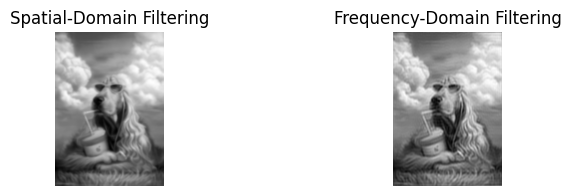

In [27]:
img=cv2.imread("dog.jpg",0)
spatial=cv2.GaussianBlur(img,(15,15),0)
f=np.fft.fftshift(np.fft.fft2(img))
rows,cols=img.shape
cy,cx=rows//2,cols//2
y,x=np.ogrid[:rows,:cols]
d=np.sqrt((x-cx)**2+(y-cy)**2)
lowpass=(d<50)
frequency=np.abs(np.fft.ifft2(np.fft.ifftshift(f*lowpass)))
plt.figure(figsize=(8,2))
plt.subplot(1,2,1)
plt.imshow(spatial,cmap="gray")
plt.title("Spatial-Domain Filtering")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(frequency,cmap="gray")
plt.title("Frequency-Domain Filtering")
plt.axis("off")
plt.show()